# Lung Cancer Classification
---

### Importing Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np
import math

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Data modeling libraries
from xgboost import XGBClassifier as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Model evaluation library
from sklearn.metrics import confusion_matrix, classification_report

### Reading the Data

In [2]:
# Read the data
df = pd.read_csv("../data/raw/dataset.csv", engine="pyarrow")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


### Initial Data Profiling
We will:
1. Check the dataset brief information (data types of each feature, what does each features represents)
2. Dataset briefly statistical information
3. Check for missing values

In [3]:
# Check the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 3000 non-null   str  
 1   AGE                    3000 non-null   int64
 2   SMOKING                3000 non-null   int64
 3   YELLOW_FINGERS         3000 non-null   int64
 4   ANXIETY                3000 non-null   int64
 5   PEER_PRESSURE          3000 non-null   int64
 6   CHRONIC_DISEASE        3000 non-null   int64
 7   FATIGUE                3000 non-null   int64
 8   ALLERGY                3000 non-null   int64
 9   WHEEZING               3000 non-null   int64
 10  ALCOHOL_CONSUMING      3000 non-null   int64
 11  COUGHING               3000 non-null   int64
 12  SHORTNESS_OF_BREATH    3000 non-null   int64
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64
 14  CHEST_PAIN             3000 non-null   int64
 15  LUNG_CANCER            3000 non-null   str  
dtyp

**About Dataset**
This dataset consists of 3.000 rows and 16 features.

**Data Fields**
1. GENDER: Gender of the patient (M for Male, F for Female)
2. AGE: Age of the patient in years
3. SMOKING: Indicates smoking status (1 for Yes, 0 for No)
4. YELLOW_FINGERS: Indicates presence of yellow fingers (1 for Yes, 0 for No)
5. ANXIETY: Indicates presence of anxiety (1 for Yes, 0 for No)
6. PEER_PRESSURE: Indicates level of peer pressure experienced by the patient (0 for None, 1 for Low, 2 for High)
7. CHRONIC_DISEASE: Indicates presence of chronic diseases (0 for None, 1 for Mild, 2 for Severe)
8. FATIGUE: Indicates presence of fatigue (1 for Yes, 0 for No)
9. ALLERGY: Indicates presence of allergies (0 for None, 1 for Mild, 2 for Severe)
10. WHEEZING: Indicates presence of wheezing (1 for Yes, 0 for No)
11. ALCOHOL_CONSUMING: Indicates alcohol consumption status (1 for Yes, 0 for No)
12. COUGHING: Indicates presence of coughing (1 for Yes, 0 for No)
13. SHORTNESS_OF_BREATH: Indicates presence of shortness of breath (1 for Yes, 0 for No)
14. SWALLOWING_DIFFICULTY: Indicates presence of swallowing difficulty (1 for Yes, 0 for No)
15. CHEST_PAIN: Indicates presence of chest pain (1 for Yes, 0 for No)
16. LUNG_CANCER: Indicates the diagnosis of lung cancer (YES for diagnosed, NO for not diagnosed)

In [4]:
# Check the distribution of the dataset
df.describe().T # Transpose

,count,mean,std,min,25%,50%,75%,max
AGE,3000.0,55.169000,14.723746,30.0,42.0,55.0,68.0,80.0
SMOKING,3000.0,1.491000,0.500002,1.0,1.0,1.0,2.0,2.0
YELLOW_FINGERS,3000.0,1.514000,0.499887,1.0,1.0,2.0,2.0,2.0
ANXIETY,3000.0,1.494000,0.500047,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,3000.0,1.499000,0.500082,1.0,1.0,1.0,2.0,2.0
CHRONIC_DISEASE,3000.0,1.509667,0.499990,1.0,1.0,2.0,2.0,2.0
FATIGUE,3000.0,1.489667,0.499977,1.0,1.0,1.0,2.0,2.0
ALLERGY,3000.0,1.506667,0.500039,1.0,1.0,2.0,2.0,2.0
WHEEZING,3000.0,1.497333,0.500076,1.0,1.0,1.0,2.0,2.0
ALCOHOL_CONSUMING,3000.0,1.491333,0.500008,1.0,1.0,1.0,2.0,2.0


In [5]:
# Check for missing values
df.isna().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
LUNG_CANCER              0
dtype: int64

There are no missing values on the dataset, therefore no need missing values handling.

### Exploratory Data Analysis (EDA)
We will check the distribution of each features.

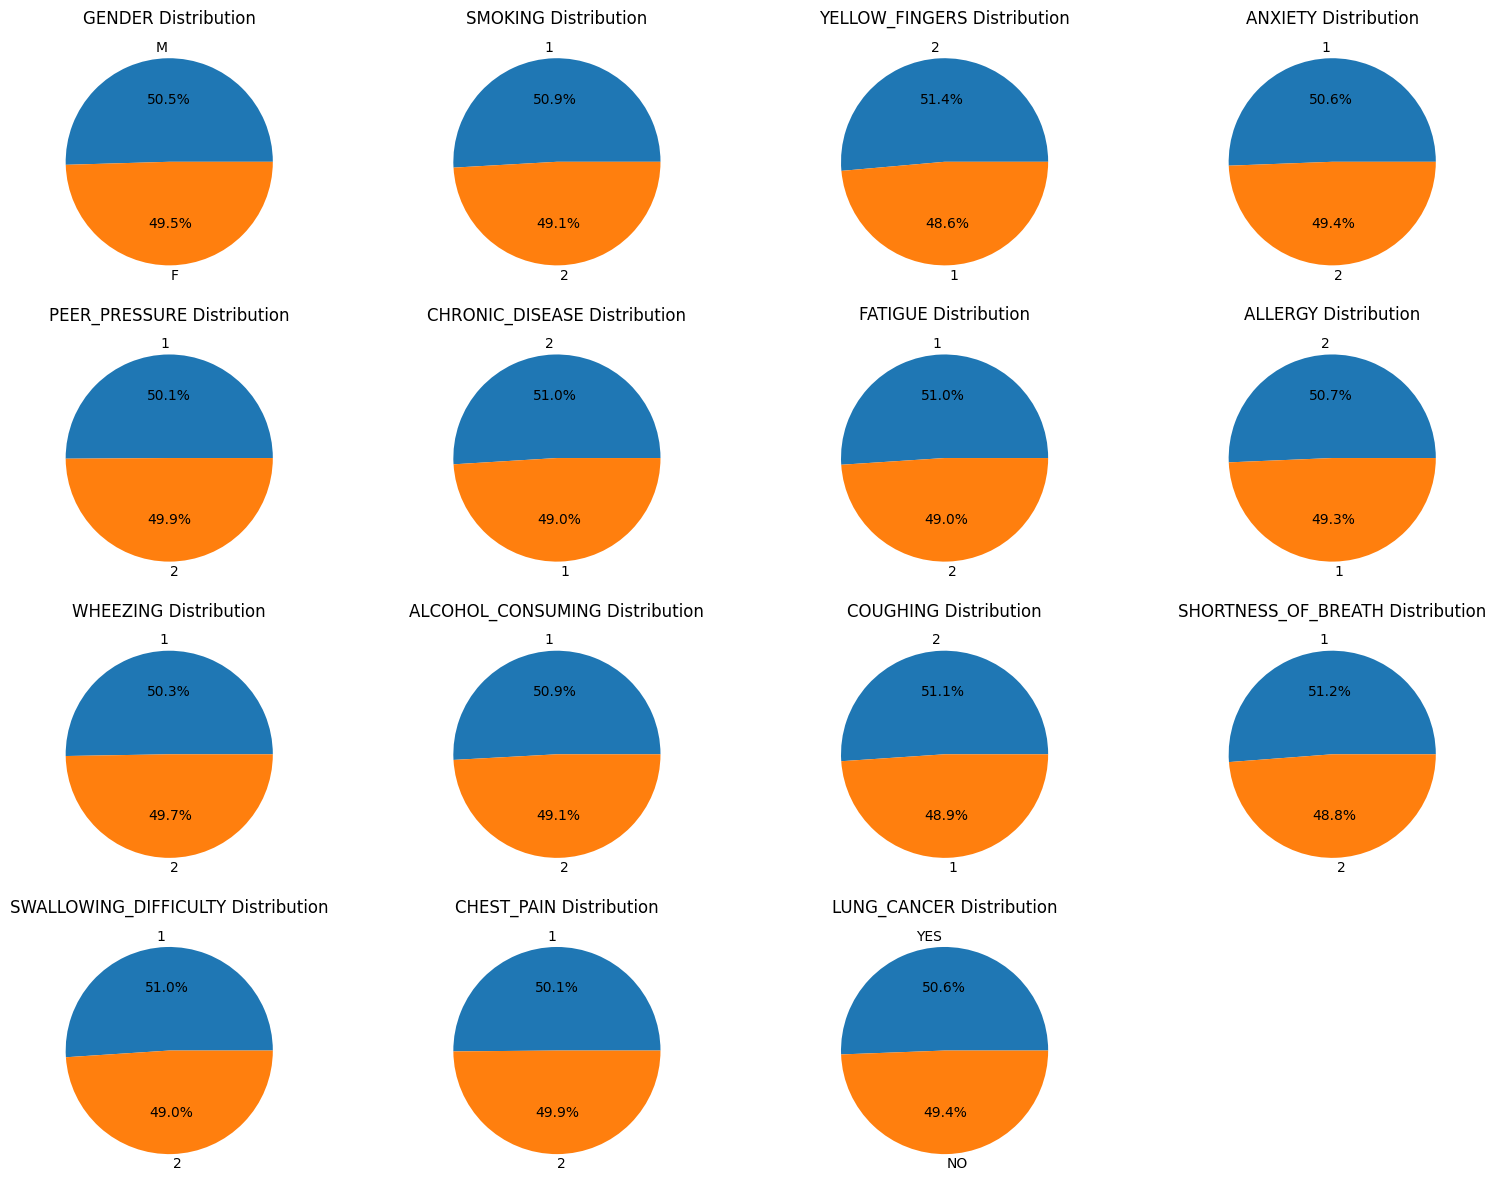

In [6]:
df_columns = ['GENDER', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
       'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
       'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER']

n_cols = 4  # number of columns in subplot grid
n_rows = math.ceil(len(df_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()  # make indexing easier

for i, col in enumerate(df_columns):
    value_counts = df[col].value_counts()
    
    axes[i].pie(
        value_counts,
        labels=value_counts.index,
        autopct='%1.1f%%'
    )
    axes[i].set_title(f"{col} Distribution")

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

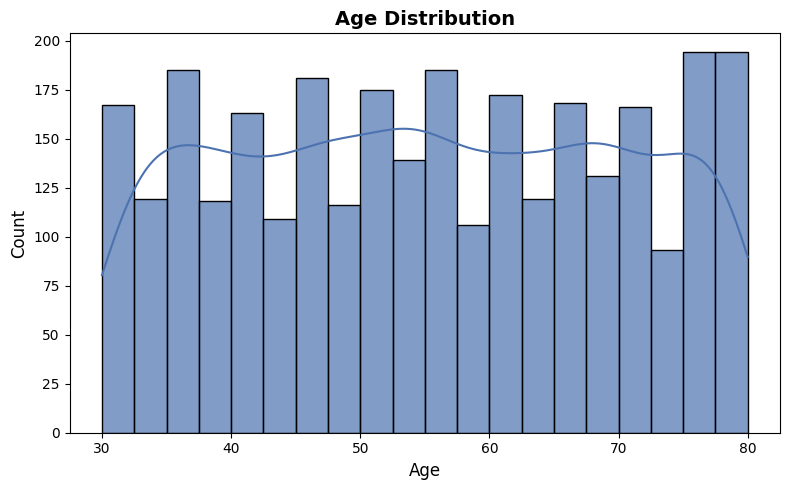

In [7]:
# Age distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="AGE",
    bins=20,
    kde=True,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.7
)

plt.title("Age Distribution", fontsize=14, weight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Data Preparation
We will:
1. Mapping GENDER and LUNG_CANCER column to numerical features
2. Feature Selection
3. Data splitting (X,y, and train test split)
4. Standardization using StandardScaler (important for LogReg and GaussianNB)

In [8]:
# confirm the data type is wrong
print(f"Data type of GENDER column: {df["GENDER"].dtype}")
print(f"Unique values of GENDER column: {df["GENDER"].unique()}\n")
print(f"Data type of LUNG_CANCER column: {df['LUNG_CANCER'].dtype}")
print(f"Unique values of LUNG_CANCER column: {df["LUNG_CANCER"].unique()}")

# Map the data
# GENDER COLUMN
df["GENDER"] = df["GENDER"].replace(['M', 'F'], [1, 0]).astype(int)

# LUNG_CANCER COLUMN
df["LUNG_CANCER"] = df["LUNG_CANCER"].replace(['YES', 'NO'], [1, 0]).astype(int)

# Check the dataset to confirm if the mapping is successful
df.info()

Data type of GENDER column: str
Unique values of GENDER column: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str

Data type of LUNG_CANCER column: str
Unique values of LUNG_CANCER column: <ArrowStringArray>
['NO', 'YES']
Length: 2, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 3000 non-null   int64
 1   AGE                    3000 non-null   int64
 2   SMOKING                3000 non-null   int64
 3   YELLOW_FINGERS         3000 non-null   int64
 4   ANXIETY                3000 non-null   int64
 5   PEER_PRESSURE          3000 non-null   int64
 6   CHRONIC_DISEASE        3000 non-null   int64
 7   FATIGUE                3000 non-null   int64
 8   ALLERGY                3000 non-null   int64
 9   WHEEZING               3000 non-null   int64
 10  ALCOHOL_CONSUMING      3000 non-null   int64
 11  COU

In [9]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,1,65,1,1,1,2,2,1,2,2,2,2,2,2,1,0
1,0,55,1,2,2,1,1,2,2,2,1,1,1,2,2,0
2,0,78,2,2,1,1,1,2,1,2,1,1,2,1,1,1
3,1,60,2,1,1,1,2,1,2,1,1,2,1,2,2,1
4,0,80,1,1,2,1,1,2,1,2,1,1,1,1,2,0


<Axes: >

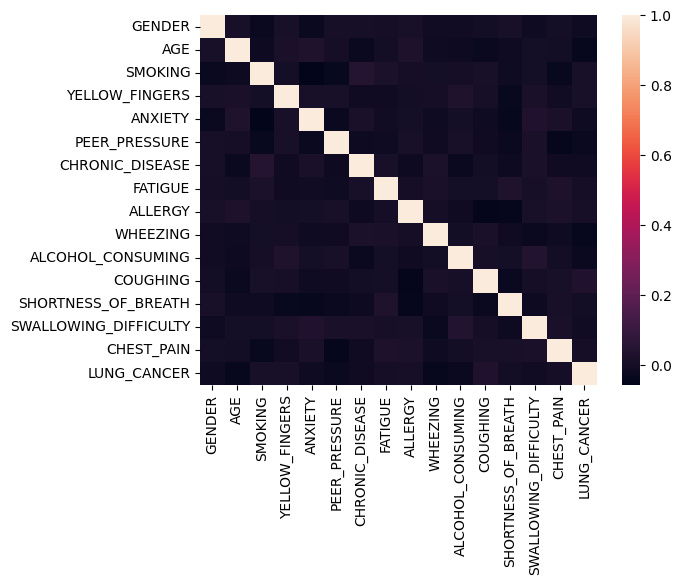

In [10]:
# Feature selection
df_corr = df.corr()
sns.heatmap(df_corr)

All feature have low correlation, so we can't use correlation matrix to do feature selection. Instead, we will use RandomForestClassifier faeture importance to do the feature selection. But before that, we need to split the Data to X and Y first.The correlation analysis shows that all features have low pairwise correlation, indicating weak linear relationships between variables and no significant redundancy. As a result, the correlation matrix is not suitable for feature selection in this case.

Since no features appear strongly correlated or redundant, all features are retained for model training to preserve as much information as possible. The dataset is then split into input features (X) and the target variable (y) before proceeding with modeling.

In [16]:
# Data splitting
X = df.drop(columns="LUNG_CANCER")
y = df['LUNG_CANCER']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Standard Scaler for LogReg and GaussianNB
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

### Modeling
Default Param

In [20]:
# LOGREG
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.47      0.50       302
           1       0.52      0.57      0.54       298

    accuracy                           0.52       600
   macro avg       0.52      0.52      0.52       600
weighted avg       0.52      0.52      0.52       600



In [21]:
# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.54      0.48      0.51       302
           1       0.52      0.58      0.55       298

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.53       600
weighted avg       0.53      0.53      0.53       600



In [15]:
# XGBClassifier
xgbc = xgb()
xgbc.fit(X_train, y_train)
y_pred_xgb = xgbc.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.49      0.45      0.47       302
           1       0.49      0.53      0.51       298

    accuracy                           0.49       600
   macro avg       0.49      0.49      0.49       600
weighted avg       0.49      0.49      0.49       600

